# Fully Supervised HAR Baseline : Subject-Wise Balanced Split

Standalone Colab notebook for the CAP66619 final project supervised baseline.

This notebook trains a fresh `ResNet1D` encoder plus MLP classification head from random initialization on the unified five-class HAR dataset using a **subject-wise approximately class-balanced split**.


In [1]:
# Install runtime dependencies.
import subprocess
import sys

subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch', 'torchvision', 'numpy', 'pandas', 'scipy',
    'scikit-learn', 'matplotlib'
], check=False)
print('Dependencies ready.')


Dependencies ready.


In [ ]:
# Mount Google Drive and configure dataset paths.
import os
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive', force_remount=False)
except Exception:
    IN_COLAB = False

# EDIT ONLY THIS BLOCK TO SET THE DRIVE FOLDER AND DATASET SUBPATHS
DRIVE_BASE = 'MyDrive/Project_Activity_detection'
DATASET_SUBPATHS = {
    'ucihar': 'UCI HAR Dataset',
    'hhar': 'HHAR/Activity recognition exp/Activity recognition exp',
    'pamap2': 'PAMAP2_Dataset',
    'motionsense': '.',
}

ROOT = Path('/content/drive') / DRIVE_BASE if IN_COLAB else Path('.').resolve()
UCI_ROOT = ROOT / DATASET_SUBPATHS['ucihar']
HHAR_ROOT = ROOT / DATASET_SUBPATHS['hhar']
PAMAP2_ROOT = ROOT / DATASET_SUBPATHS['pamap2']
MSENSE_ROOT = ROOT / DATASET_SUBPATHS['motionsense']

CKPT_DIR = ROOT / 'checkpoints_supervised_baseline_subjectwise_balanced'
FIG_DIR = ROOT / 'figures_supervised_baseline_subjectwise_balanced'
RES_DIR = ROOT / 'results_supervised_baseline_subjectwise_balanced'
for directory in [CKPT_DIR, FIG_DIR, RES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print('Dataset paths:')
for name, path in [('UCI-HAR', UCI_ROOT), ('HHAR', HHAR_ROOT), ('PAMAP2', PAMAP2_ROOT), ('MotionSense', MSENSE_ROOT)]:
    status = 'OK' if path.exists() else 'MISSING'
    print(f'  {name:<12} {path} [{status}]')
print(f'Results directory: {RES_DIR}')


Mounted at /content/drive
Dataset paths:
  UCI-HAR      /content/drive/MyDrive/Project_Activity_detection/UCI HAR Dataset [OK]
  HHAR         /content/drive/MyDrive/Project_Activity_detection/HHAR/Activity recognition exp/Activity recognition exp [OK]
  PAMAP2       /content/drive/MyDrive/Project_Activity_detection/PAMAP2_Dataset [OK]
  MotionSense  /content/drive/MyDrive/Project_Activity_detection [OK]
Results directory: /content/drive/MyDrive/Project_Activity_detection/results_supervised_baseline_subjectwise_balanced


In [3]:
# Imports, constants, and reproducibility.
import random
import re

import numpy as np
import pandas as pd
from scipy import signal as sp_signal
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt

SEED = 42
BATCH_SIZE = 256
N_CLASSES = 5
CLASS_NAMES = ['walking', 'upstairs', 'downstairs', 'sitting', 'standing']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')


Device: cuda | PyTorch: 2.10.0+cu128


In [4]:
# Dataset loaders. All loaders return X with shape (N, 128, 6), y in [0..4], and subjects.

WINDOW_LEN = 128
STRIDE = 64
TARGET_FS = 50


def _slide_windows(data, window_len=WINDOW_LEN, stride=STRIDE, n_channels=6):
    starts = list(range(0, len(data) - window_len + 1, stride))
    if not starts:
        return np.empty((0, window_len, n_channels), dtype=np.float32)
    return np.stack([data[s:s + window_len] for s in starts]).astype(np.float32)


def _contiguous_runs(mask):
    in_run = False
    start = 0
    for i, value in enumerate(mask):
        if value and not in_run:
            start = i
            in_run = True
        elif not value and in_run:
            yield start, i
            in_run = False
    if in_run:
        yield start, len(mask)


def load_ucihar(root):
    root = Path(root)
    activity_map = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}

    def _load_split(split):
        sig_dir = root / split / 'Inertial Signals'
        channels = []
        for sensor in ['body_acc', 'body_gyro']:
            for axis in ['x', 'y', 'z']:
                channels.append(np.loadtxt(sig_dir / f'{sensor}_{axis}_{split}.txt'))
        X = np.stack(channels, axis=-1)
        y = np.loadtxt(root / split / f'y_{split}.txt', dtype=int)
        subjects = np.loadtxt(root / split / f'subject_{split}.txt', dtype=int)
        return X, y, subjects

    X_train, y_train, s_train = _load_split('train')
    X_test, y_test, s_test = _load_split('test')
    X = np.concatenate([X_train, X_test], axis=0)
    y = np.concatenate([y_train, y_test], axis=0)
    subjects = np.concatenate([s_train, s_test], axis=0)
    mask = np.isin(y, list(activity_map.keys()))
    X = X[mask]
    y = np.array([activity_map[int(label)] for label in y[mask]], dtype=np.int64)
    subjects = subjects[mask].astype(np.int64)
    return X.astype(np.float32), y, subjects


def load_hhar(root, device_type='phone'):
    root = Path(root)
    activity_map = {'walk': 0, 'stairsup': 1, 'stairsdown': 2, 'sit': 3, 'stand': 4}
    prefix = 'Phones' if device_type == 'phone' else 'Watch'
    acc_df = pd.read_csv(root / f'{prefix}_accelerometer.csv')
    gyr_df = pd.read_csv(root / f'{prefix}_gyroscope.csv')
    acc_df = acc_df[acc_df['gt'].isin(activity_map)].copy()
    gyr_df = gyr_df[gyr_df['gt'].isin(activity_map)].copy()
    acc_df.sort_values(['User', 'Device', 'gt', 'Creation_Time'], inplace=True)
    gyr_df.sort_values(['User', 'Device', 'gt', 'Creation_Time'], inplace=True)
    user_map = {u: i for i, u in enumerate(sorted(acc_df['User'].unique()))}

    def _estimate_fs(timestamps_ns):
        diffs = np.diff(timestamps_ns)
        diffs = diffs[diffs > 0]
        if len(diffs) == 0:
            return TARGET_FS
        median_dt_s = np.median(diffs) * 1e-9
        return 1.0 / median_dt_s if median_dt_s > 0 else TARGET_FS

    def _resample(data, source_fs):
        if abs(source_fs - TARGET_FS) < 2.0:
            return data
        n_out = max(1, int(round(len(data) * TARGET_FS / source_fs)))
        return sp_signal.resample(data, n_out, axis=0)

    windows, labels, subjects = [], [], []
    for (user, device, gt), acc_grp in acc_df.groupby(['User', 'Device', 'gt']):
        gyr_grp = gyr_df[(gyr_df['User'] == user) & (gyr_df['Device'] == device) & (gyr_df['gt'] == gt)]
        if len(acc_grp) < WINDOW_LEN or len(gyr_grp) < WINDOW_LEN:
            continue
        source_fs = _estimate_fs(acc_grp['Creation_Time'].values)
        acc_xyz = acc_grp[['x', 'y', 'z']].values.astype(np.float32)
        gyr_xyz = gyr_grp[['x', 'y', 'z']].values.astype(np.float32)
        n_min = min(len(acc_xyz), len(gyr_xyz))
        acc_xyz = _resample(acc_xyz[:n_min], source_fs)
        gyr_xyz = _resample(gyr_xyz[:n_min], source_fs)
        n_min = min(len(acc_xyz), len(gyr_xyz))
        data = np.concatenate([acc_xyz[:n_min], gyr_xyz[:n_min]], axis=1)
        wins = _slide_windows(data)
        if len(wins) == 0:
            continue
        windows.append(wins)
        labels.extend([activity_map[gt]] * len(wins))
        subjects.extend([user_map[user]] * len(wins))
    return np.concatenate(windows).astype(np.float32), np.array(labels, dtype=np.int64), np.array(subjects, dtype=np.int64)


def load_pamap2(root):
    root = Path(root)
    activity_map = {4: 0, 12: 1, 13: 2, 2: 3, 3: 4}
    sensor_cols = [21, 22, 23, 27, 28, 29]
    protocol_candidates = [root / 'Protocol', root / 'PAMAP2_Dataset' / 'Protocol', root]
    protocol_dir = None
    dat_files = []
    for candidate in protocol_candidates:
        dat_files = sorted(candidate.glob('subject*.dat')) if candidate.exists() else []
        if dat_files:
            protocol_dir = candidate
            break
    if not dat_files:
        for candidate in sorted(root.glob('**/Protocol')):
            dat_files = sorted(candidate.glob('subject*.dat'))
            if dat_files:
                protocol_dir = candidate
                break
    if not dat_files:
        raise FileNotFoundError(f'No PAMAP2 subject*.dat files found under {root}')

    windows, labels, subjects = [], [], []
    for fallback_id, dat_file in enumerate(dat_files):
        match = re.search(r'subject(\d+)', dat_file.stem)
        subject_id = int(match.group(1)) if match else fallback_id
        df = pd.read_csv(dat_file, sep=r'\s+', header=None, na_values=['NaN', 'nan']).astype(float)
        activity_ids = pd.to_numeric(df.iloc[:, 1], errors='coerce').fillna(0).values.astype(int)
        sensor_df = df.iloc[:, sensor_cols].copy().interpolate(method='linear', limit_direction='both')
        sensor_data = sensor_df.values.astype(np.float32)
        sensor_ds = sensor_data[::2]
        activity_ds = activity_ids[::2]
        for activity_id, target_label in activity_map.items():
            mask = activity_ds == activity_id
            for start, end in _contiguous_runs(mask):
                wins = _slide_windows(sensor_ds[start:end])
                if len(wins) == 0:
                    continue
                windows.append(wins)
                labels.extend([target_label] * len(wins))
                subjects.extend([subject_id] * len(wins))
    print(f'PAMAP2 protocol directory: {protocol_dir}')
    return np.concatenate(windows).astype(np.float32), np.array(labels, dtype=np.int64), np.array(subjects, dtype=np.int64)


def load_motionsense(root):
    root = Path(root)
    activity_map = {'dws': 2, 'ups': 1, 'sit': 3, 'std': 4, 'wlk': 0}
    acc_cols = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
    gyr_cols = ['rotationRate.x', 'rotationRate.y', 'rotationRate.z']
    needed = acc_cols + gyr_cols
    windows, labels, subjects = [], [], []
    if not root.exists():
        raise FileNotFoundError(f'MotionSense root does not exist: {root}')
    candidate_roots = [root / 'DeviceMotion_data', root / 'A_DeviceMotion_data', root]
    candidate_roots.extend(sorted(root.rglob('DeviceMotion_data')))
    candidate_roots.extend(sorted(root.rglob('A_DeviceMotion_data')))
    activity_dirs = []
    seen_dirs = set()

    for data_root in candidate_roots:
        if not data_root.exists():
            continue
        for act_dir in [data_root] + sorted(data_root.rglob('*')):
            if not act_dir.is_dir():
                continue
            activity_code = re.split(r'[_\-]', act_dir.name)[0].lower()
            if activity_code not in activity_map:
                continue
            csv_files = sorted(act_dir.glob('*.csv'))
            if not csv_files:
                continue
            try:
                header = pd.read_csv(csv_files[0], nrows=0)
            except Exception:
                continue
            columns = {str(col).strip() for col in header.columns}
            if not all(col in columns for col in needed):
                continue
            resolved = act_dir.resolve()
            if resolved in seen_dirs:
                continue
            seen_dirs.add(resolved)
            activity_dirs.append((act_dir, activity_code))

    if not activity_dirs:
        raise FileNotFoundError(
            'MotionSense loader found no usable DeviceMotion activity folders below '
            f'{root}. Expected dws_*/sub_*.csv, ups_*/sub_*.csv, sit_*/sub_*.csv, '
            f'std_*/sub_*.csv, or wlk_*/sub_*.csv with columns {needed}. '
            'Use folder A_DeviceMotion_data / DeviceMotion_data, not Accelerometer_data or Gyroscope_data.'
        )

    for act_dir, activity_code in activity_dirs:
        label = activity_map[activity_code]
        for csv_file in sorted(act_dir.glob('*.csv')):
            digits = re.findall(r'\d+', csv_file.stem)
            if not digits:
                continue
            df = pd.read_csv(csv_file)
            df.columns = [str(col).strip() for col in df.columns]
            if any(col not in df.columns for col in needed):
                continue
            data = df[needed].dropna().values.astype(np.float32)
            wins = _slide_windows(data)
            if len(wins) == 0:
                continue
            windows.append(wins)
            labels.extend([label] * len(wins))
            subjects.extend([int(digits[-1])] * len(wins))
    if not windows:
        raise ValueError(
            'MotionSense files were found, but no 128-sample windows were created. '
            f'Check that files under {root} have at least 128 rows after dropna().'
        )
    return np.concatenate(windows).astype(np.float32), np.array(labels, dtype=np.int64), np.array(subjects, dtype=np.int64)


In [5]:
# Unified subject-wise approximately class-balanced train/validation/test split with train-only normalization.

DATASET_IDS = {'ucihar': 0, 'hhar': 1, 'pamap2': 2, 'motionsense': 3}
DATASET_NAMES = {value: key for key, value in DATASET_IDS.items()}


class HARDataset(Dataset):

    def __init__(self, X, y, subjects, sources):

        self.X = torch.from_numpy(X.transpose(0, 2, 1)).float()

        self.y = torch.from_numpy(y).long()

        self.subjects = np.asarray(subjects)

        self.sources = np.asarray(sources)


    def __len__(self):

        return len(self.y)


    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]



def _prepare_unified_arrays(datasets):

    all_X, all_y, all_sub, all_src = [], [], [], []

    dataset_ranges = {}

    start = 0

    subject_offset = 0


    for name, (X, y, subjects) in datasets.items():

        source_id = DATASET_IDS[name]

        subjects = subjects.astype(np.int64) + subject_offset

        all_X.append(X)

        all_y.append(y)

        all_sub.append(subjects)

        all_src.append(np.full(len(y), source_id, dtype=np.int64))

        dataset_ranges[name] = np.arange(start, start + len(y))

        start += len(y)

        subject_offset = int(subjects.max()) + 1


    return (

        np.concatenate(all_X, axis=0),

        np.concatenate(all_y, axis=0),

        np.concatenate(all_sub, axis=0),

        np.concatenate(all_src, axis=0),

        dataset_ranges,

    )



def _subject_histograms(labels, subjects):

    unique_subjects = np.unique(subjects)

    hist = {}

    for sid in unique_subjects:

        hist[sid] = np.bincount(labels[subjects == sid], minlength=N_CLASSES).astype(np.float64)

    return unique_subjects, hist



def _balanced_subject_split(labels, subjects, val_fraction=0.10, test_fraction=0.20, seed=42):

    unique_subjects, hist = _subject_histograms(labels, subjects)

    n_subjects = len(unique_subjects)

    if n_subjects < 3:

        raise ValueError(f'Need at least 3 subjects for train/val/test split, got {n_subjects}.')


    rng = np.random.default_rng(seed)

    total_hist = np.bincount(labels, minlength=N_CLASSES).astype(np.float64)

    target_fracs = {'train': 1.0 - val_fraction - test_fraction, 'val': val_fraction, 'test': test_fraction}

    target_subjects = {

        'test': max(1, int(round(n_subjects * test_fraction))),

        'val': max(1, int(round(n_subjects * val_fraction))),

    }

    if target_subjects['test'] + target_subjects['val'] >= n_subjects:

        target_subjects['test'] = min(target_subjects['test'], n_subjects - 2)

        target_subjects['val'] = min(target_subjects['val'], n_subjects - target_subjects['test'] - 1)

    target_subjects['train'] = n_subjects - target_subjects['val'] - target_subjects['test']


    target_hist = {k: total_hist * frac for k, frac in target_fracs.items()}

    assigned = {'train': [], 'val': [], 'test': []}

    current_hist = {k: np.zeros(N_CLASSES, dtype=np.float64) for k in assigned}

    current_subjects = {k: 0 for k in assigned}

    current_windows = {k: 0.0 for k in assigned}


    order = list(unique_subjects)

    rng.shuffle(order)

    order.sort(key=lambda sid: hist[sid].sum(), reverse=True)


    for sid in order:

        sid_hist = hist[sid]

        remaining = len(order) - sum(current_subjects.values())


        candidates = []

        for split in ('train', 'val', 'test'):

            if current_subjects[split] >= target_subjects[split]:

                continue

            needed_elsewhere = sum(max(0, target_subjects[s] - current_subjects[s]) for s in ('train', 'val', 'test') if s != split)

            if remaining - 1 < needed_elsewhere:

                continue

            candidates.append(split)


        if not candidates:

            candidates = [split for split in ('train', 'val', 'test') if current_subjects[split] < target_subjects[split]]


        best_split = None

        best_score = None

        for split in candidates:

            new_hist = current_hist[split] + sid_hist

            class_score = np.abs(target_hist[split] - new_hist).sum()

            size_score = abs(target_hist[split].sum() - (current_windows[split] + sid_hist.sum()))

            subject_score = abs(target_subjects[split] - (current_subjects[split] + 1))

            score = class_score + 0.25 * size_score + 5.0 * subject_score

            if best_score is None or score < best_score:

                best_score = score

                best_split = split


        assigned[best_split].append(sid)

        current_hist[best_split] += sid_hist

        current_subjects[best_split] += 1

        current_windows[best_split] += sid_hist.sum()


    if not assigned['train'] or not assigned['val'] or not assigned['test']:

        raise ValueError('Balanced subject split produced an empty split.')


    return (

        np.array(assigned['train'], dtype=subjects.dtype),

        np.array(assigned['val'], dtype=subjects.dtype),

        np.array(assigned['test'], dtype=subjects.dtype),

    )



def build_unified_dataset(datasets, val_fraction=0.10, test_fraction=0.20, seed=42):

    X, y, subjects, sources, dataset_ranges = _prepare_unified_arrays(datasets)


    train_parts, val_parts, test_parts = [], [], []


    for ds_i, (name, idxs) in enumerate(dataset_ranges.items()):

        tr_subj, va_subj, te_subj = _balanced_subject_split(

            y[idxs],

            subjects[idxs],

            val_fraction=val_fraction,

            test_fraction=test_fraction,

            seed=seed + ds_i,

        )


        train_parts.append(idxs[np.isin(subjects[idxs], tr_subj)])

        val_parts.append(idxs[np.isin(subjects[idxs], va_subj)])

        test_parts.append(idxs[np.isin(subjects[idxs], te_subj)])


    train_idx = np.sort(np.concatenate(train_parts))

    val_idx = np.sort(np.concatenate(val_parts))

    test_idx = np.sort(np.concatenate(test_parts))


    if set(subjects[train_idx]) & set(subjects[val_idx]) or set(subjects[train_idx]) & set(subjects[test_idx]) or set(subjects[val_idx]) & set(subjects[test_idx]):

        raise RuntimeError('Subject overlap detected between splits.')


    _, T, C = X.shape

    scaler = StandardScaler()

    scaler.fit(X[train_idx].reshape(-1, C))


    def normalize(indices):

        Xn = scaler.transform(X[indices].reshape(-1, C)).reshape(-1, T, C)

        return Xn.astype(np.float32)


    return {

        'train': HARDataset(normalize(train_idx), y[train_idx], subjects[train_idx], sources[train_idx]),

        'val': HARDataset(normalize(val_idx), y[val_idx], subjects[val_idx], sources[val_idx]),

        'test': HARDataset(normalize(test_idx), y[test_idx], subjects[test_idx], sources[test_idx]),

        'scaler': scaler,

        'meta': {

            'train_idx': train_idx,

            'val_idx': val_idx,

            'test_idx': test_idx,

            'train_subjects': subjects[train_idx],

            'val_subjects': subjects[val_idx],

            'test_subjects': subjects[test_idx],

            'test_sources': sources[test_idx],

        },

    }


In [6]:
# ResNet1D supervised classifier.

class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1):
        super().__init__()
        pad = kernel // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel, stride=stride, padding=pad, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel, padding=pad, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.act = nn.ReLU(inplace=True)
        self.skip = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )

    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + self.skip(x))


class ResNet1D(nn.Module):
    def __init__(self, in_channels=6, base_filters=64):
        super().__init__()
        f = base_filters
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, f, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(f),
            nn.ReLU(inplace=True),
        )
        self.layer1 = ResBlock1D(f, f, stride=1)
        self.layer2 = ResBlock1D(f, f * 2, stride=2)
        self.layer3 = ResBlock1D(f * 2, f * 4, stride=2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.out_dim = f * 4

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.gap(x).squeeze(-1)


class SupervisedHARModel(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.encoder = ResNet1D(in_channels=6, base_filters=64)
        self.head = nn.Sequential(
            nn.Linear(self.encoder.out_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.head(self.encoder(x))


In [7]:
# Metrics: accuracy, macro-F1, calibration, temperature scaling, and conformal coverage.

def softmax_np(logits):
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return (exp / exp.sum(axis=1, keepdims=True)).astype(np.float32)


def compute_accuracy(probs, labels):
    return float(accuracy_score(labels, probs.argmax(axis=1)))


def compute_macro_f1(probs, labels):
    return float(f1_score(labels, probs.argmax(axis=1), average='macro', zero_division=0))


def compute_ece(probs, labels, n_bins=15):
    conf = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    correct = (preds == labels).astype(float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            continue
        ece += mask.mean() * abs(correct[mask].mean() - conf[mask].mean())
    return float(ece)


def compute_mce(probs, labels, n_bins=15):
    conf = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    correct = (preds == labels).astype(float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    mce = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() > 0:
            mce = max(mce, abs(correct[mask].mean() - conf[mask].mean()))
    return float(mce)


def compute_nll(probs, labels):
    return float(-np.log(probs[np.arange(len(labels)), labels] + 1e-10).mean())


def compute_brier(probs, labels):
    onehot = np.eye(probs.shape[1])[labels]
    return float(((probs - onehot) ** 2).sum(axis=1).mean())


def reliability_diagram_data(probs, labels, n_bins=15):
    conf = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    correct = (preds == labels).astype(float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_confidences, bin_accuracies, bin_counts = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        count = int(mask.sum())
        bin_counts.append(count)
        if count == 0:
            bin_confidences.append(float((lo + hi) / 2))
            bin_accuracies.append(0.0)
        else:
            bin_confidences.append(float(conf[mask].mean()))
            bin_accuracies.append(float(correct[mask].mean()))
    return {
        'bin_confidences': np.array(bin_confidences),
        'bin_accuracies': np.array(bin_accuracies),
        'bin_counts': np.array(bin_counts),
        'ece': compute_ece(probs, labels, n_bins),
        'mce': compute_mce(probs, labels, n_bins),
    }


def fit_temperature(logits, labels, lr=0.01, max_iter=1000):
    logits_t = torch.from_numpy(logits).float()
    labels_t = torch.from_numpy(labels).long()
    temperature = torch.nn.Parameter(torch.ones(1))
    optimizer = torch.optim.LBFGS([temperature], lr=lr, max_iter=max_iter)

    def closure():
        optimizer.zero_grad()
        loss = F.cross_entropy(logits_t / temperature.clamp(min=1e-4), labels_t)
        loss.backward()
        return loss

    optimizer.step(closure)
    return float(temperature.item())


def apply_temperature(logits, temperature):
    return softmax_np(logits / temperature)


def conformal_evaluate(probs_cal, labels_cal, probs_test, labels_test, alpha=0.10):
    n = len(labels_cal)
    scores = 1.0 - probs_cal[np.arange(n), labels_cal]
    level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
    q = float(np.quantile(scores, level, method='higher'))
    sets = probs_test >= (1.0 - q)
    return {
        'q_threshold': q,
        'empirical_coverage': float(sets[np.arange(len(labels_test)), labels_test].mean()),
        'avg_set_size': float(sets.sum(axis=1).mean()),
        'singleton_rate': float((sets.sum(axis=1) == 1).mean()),
        'empty_rate': float((sets.sum(axis=1) == 0).mean()),
    }


def full_evaluation(logits_test, labels_test, logits_cal, labels_cal, alpha=0.10, n_bins=15):
    probs_raw = softmax_np(logits_test)
    temperature = fit_temperature(logits_cal, labels_cal)
    probs_ts = apply_temperature(logits_test, temperature)
    probs_cal_ts = apply_temperature(logits_cal, temperature)

    results = {
        'raw_acc': compute_accuracy(probs_raw, labels_test),
        'raw_f1': compute_macro_f1(probs_raw, labels_test),
        'raw_ece': compute_ece(probs_raw, labels_test, n_bins),
        'raw_mce': compute_mce(probs_raw, labels_test, n_bins),
        'raw_nll': compute_nll(probs_raw, labels_test),
        'raw_brier': compute_brier(probs_raw, labels_test),
        'ts_acc': compute_accuracy(probs_ts, labels_test),
        'ts_f1': compute_macro_f1(probs_ts, labels_test),
        'ts_ece': compute_ece(probs_ts, labels_test, n_bins),
        'ts_mce': compute_mce(probs_ts, labels_test, n_bins),
        'ts_nll': compute_nll(probs_ts, labels_test),
        'ts_brier': compute_brier(probs_ts, labels_test),
        'temperature': temperature,
        'conformal': conformal_evaluate(probs_cal_ts, labels_cal, probs_ts, labels_test, alpha),
        'reliability_raw': reliability_diagram_data(probs_raw, labels_test, n_bins),
        'reliability_ts': reliability_diagram_data(probs_ts, labels_test, n_bins),
    }
    return results


In [8]:
# Training and inference helpers.

def train_supervised(model, train_loader, val_loader, n_epochs=50, lr=1e-3, weight_decay=1e-4):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr * 0.01)
    history = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        scheduler.step()

        val_loss, val_acc = evaluate_loader_loss_acc(model, val_loader)
        row = {
            'epoch': epoch,
            'train_loss': train_loss / max(len(train_loader), 1),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'lr': optimizer.param_groups[0]['lr'],
        }
        history.append(row)
        if epoch == 1 or epoch % 5 == 0 or epoch == n_epochs:
            print(f"Epoch {epoch:03d}/{n_epochs} | train_loss={row['train_loss']:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")
    return history


@torch.no_grad()
def evaluate_loader_loss_acc(model, loader):
    model.eval()
    total_loss, total_n, correct = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = F.cross_entropy(logits, y, reduction='sum')
        total_loss += float(loss.item())
        total_n += int(y.numel())
        correct += int((logits.argmax(dim=1) == y).sum().item())
    return total_loss / max(total_n, 1), correct / max(total_n, 1)


@torch.no_grad()
def collect_logits(model, loader):
    model.eval()
    logits_all, labels_all = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        logits = model(x)
        logits_all.append(logits.cpu().numpy())
        labels_all.append(y.numpy())
    return np.concatenate(logits_all).astype(np.float32), np.concatenate(labels_all)


In [9]:
# Load all four datasets.
print('Loading UCI-HAR...')
X_uci, y_uci, s_uci = load_ucihar(UCI_ROOT)
print(f'  UCI-HAR: {X_uci.shape}')

print('Loading HHAR...')
X_hhar, y_hhar, s_hhar = load_hhar(HHAR_ROOT, device_type='phone')
print(f'  HHAR: {X_hhar.shape}')

print('Loading PAMAP2...')
X_pamap2, y_pamap2, s_pamap2 = load_pamap2(PAMAP2_ROOT)
print(f'  PAMAP2: {X_pamap2.shape}')

print('Loading MotionSense...')
X_ms, y_ms, s_ms = load_motionsense(MSENSE_ROOT)
print(f'  MotionSense: {X_ms.shape}')

datasets = {
    'ucihar': (X_uci, y_uci, s_uci),
    'hhar': (X_hhar, y_hhar, s_hhar),
    'pamap2': (X_pamap2, y_pamap2, s_pamap2),
    'motionsense': (X_ms, y_ms, s_ms),
}

for name, (_, y, _) in datasets.items():
    counts = np.bincount(y, minlength=N_CLASSES)
    print(f'{name:<12}', dict(zip(CLASS_NAMES, counts.tolist())))


Loading UCI-HAR...
  UCI-HAR: (8355, 128, 6)
Loading HHAR...
  HHAR: (44130, 128, 6)
Loading PAMAP2...
PAMAP2 protocol directory: /content/drive/MyDrive/Project_Activity_detection/PAMAP2_Dataset/Protocol
  PAMAP2: (6446, 128, 6)
Loading MotionSense...
  MotionSense: (19514, 128, 6)
ucihar       {'walking': 1722, 'upstairs': 1544, 'downstairs': 1406, 'sitting': 1777, 'standing': 1906}
hhar         {'walking': 10264, 'upstairs': 8220, 'downstairs': 7267, 'sitting': 9630, 'standing': 8749}
pamap2       {'walking': 1853, 'upstairs': 892, 'downstairs': 794, 'sitting': 1435, 'standing': 1472}
motionsense  {'walking': 5275, 'upstairs': 2350, 'downstairs': 1952, 'sitting': 5221, 'standing': 4716}


In [10]:
# Build subject-wise balanced split and data loaders.

splits = build_unified_dataset(datasets, val_fraction=0.10, test_fraction=0.20, seed=SEED)
train_ds, val_ds, test_ds = splits['train'], splits['val'], splits['test']

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(DEVICE == 'cuda'))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(DEVICE == 'cuda'))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(DEVICE == 'cuda'))

print(f'Train/Val/Test: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}')


Train/Val/Test: 51300 / 9024 / 18121


In [11]:
# Train the fully supervised baseline.
SUPERVISED_EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-4

model = SupervisedHARModel(n_classes=N_CLASSES)
history = train_supervised(model, train_loader, val_loader, n_epochs=SUPERVISED_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY)

history_df = pd.DataFrame(history)
history_path = RES_DIR / 'supervised_baseline_subjectwise_balanced_training_history.csv'
history_df.to_csv(history_path, index=False)
torch.save({'model_state_dict': model.state_dict(), 'history': history}, CKPT_DIR / 'supervised_resnet1d_baseline.pt')
print(f'Saved training history to {history_path}')
print(f'Saved checkpoint to {CKPT_DIR / "supervised_resnet1d_baseline.pt"}')


Epoch 001/50 | train_loss=0.3555 | val_loss=0.8395 | val_acc=0.6730
Epoch 005/50 | train_loss=0.1471 | val_loss=1.5658 | val_acc=0.7371
Epoch 010/50 | train_loss=0.1204 | val_loss=0.9579 | val_acc=0.7677
Epoch 015/50 | train_loss=0.0906 | val_loss=0.7625 | val_acc=0.7873
Epoch 020/50 | train_loss=0.0732 | val_loss=0.9364 | val_acc=0.7614
Epoch 025/50 | train_loss=0.0625 | val_loss=1.0051 | val_acc=0.7937
Epoch 030/50 | train_loss=0.0474 | val_loss=1.1739 | val_acc=0.7745
Epoch 035/50 | train_loss=0.0347 | val_loss=0.9551 | val_acc=0.7983
Epoch 040/50 | train_loss=0.0253 | val_loss=1.0821 | val_acc=0.7917
Epoch 045/50 | train_loss=0.0179 | val_loss=1.0407 | val_acc=0.8090
Epoch 050/50 | train_loss=0.0151 | val_loss=1.0336 | val_acc=0.8096
Saved training history to /content/drive/MyDrive/Project_Activity_detection/results_supervised_baseline_subjectwise_balanced/supervised_baseline_subjectwise_balanced_training_history.csv
Saved checkpoint to /content/drive/MyDrive/Project_Activity_detec

In [12]:
# Evaluate on the held-out test set with calibration and conformal coverage.
logits_test, labels_test = collect_logits(model, test_loader)
logits_cal, labels_cal = collect_logits(model, val_loader)
results = full_evaluation(logits_test, labels_test, logits_cal, labels_cal, alpha=0.10, n_bins=15)
conf = results['conformal']

summary = pd.DataFrame([{
    'Method': 'Supervised_baseline',
    'Acc': results['raw_acc'],
    'Macro-F1': results['raw_f1'],
    'ECE (raw)': results['raw_ece'],
    'ECE (T-sc)': results['ts_ece'],
    'T': results['temperature'],
    'NLL': results['raw_nll'],
    'Brier': results['raw_brier'],
    'Coverage': conf['empirical_coverage'],
    'Avg Set': conf['avg_set_size'],
    'Singleton Rate': conf['singleton_rate'],
    'Empty Rate': conf['empty_rate'],
}])

display(summary)
summary_path = RES_DIR / 'supervised_baseline_subjectwise_balanced_summary.csv'
summary.to_csv(summary_path, index=False)
print(f'Saved summary to {summary_path}')


,Method,Acc,Macro-F1,ECE (raw),ECE (T-sc),T,NLL,Brier,Coverage,Avg Set,Singleton Rate,Empty Rate
0,Supervised_baseline,0.883285,0.873669,0.080795,0.026391,2.92647,0.641726,0.196633,0.937697,1.238618,0.785111,0.0


Saved summary to /content/drive/MyDrive/Project_Activity_detection/results_supervised_baseline_subjectwise_balanced/supervised_baseline_subjectwise_balanced_summary.csv


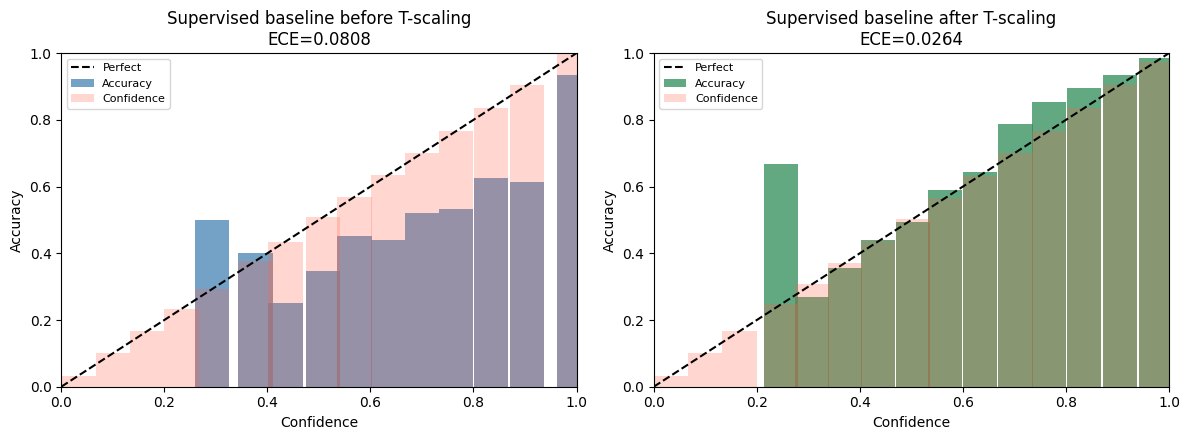

Saved reliability figure to /content/drive/MyDrive/Project_Activity_detection/figures_supervised_baseline_subjectwise_balanced/supervised_baseline_reliability.png


In [13]:
# Reliability diagrams before and after temperature scaling.
def plot_reliability(ax, rd, title, color):
    bc = rd['bin_confidences']
    ba = rd['bin_accuracies']
    width = 1.0 / len(bc)
    ax.bar(bc, ba, width=width, alpha=0.75, color=color, align='center', label='Accuracy')
    ax.bar(bc, bc, width=width, alpha=0.25, color='tomato', align='center', label='Confidence')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_title(f"{title}\nECE={rd['ece']:.4f}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_reliability(axes[0], results['reliability_raw'], 'Supervised baseline before T-scaling', 'steelblue')
plot_reliability(axes[1], results['reliability_ts'], 'Supervised baseline after T-scaling', 'seagreen')
plt.tight_layout()
fig_path = FIG_DIR / 'supervised_baseline_reliability.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved reliability figure to {fig_path}')
